In [1]:
# import general libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.optimize import fsolve
# import own classes
from agent_game_sim import QLearningAgent
from agent_game_sim import Game
from agent_game_sim import Simulation
# import own functions
from agent_game_sim import reward_matrix_for_two_player_MP # Matching Pennies
from agent_game_sim import reward_matrix_for_two_player_SH # Stag Hunt
from agent_game_sim import reward_matrix_for_two_player_BS # Bach or Stravinsky
from agent_game_sim import get_individual_matrices
from agent_game_sim import generate_q_values

# Set a fixed random seed for reproducibility
np.random.seed(42)

# Stochastic Plots

In [2]:
def run_stochastic_simulation(reward_function, num_time_steps, base_value, num_runs,
                               learning_rate, discount_factor, temperature,
                               initial_probability_pairs, split_groups=True):
    """
    Run stochastic Q-learning simulation and return grouped trajectories.
    
    Parameters
    ----------
    reward_function : callable
        Reward function for the game.
    num_time_steps : int
        Number of time steps to simulate.
    base_value : float
        Base value for Q-value initialization.
    num_runs : int
        Number of runs per initial probability pair.
    learning_rate : float
        Learning rate for Q-learning.
    discount_factor : float
        Discount factor for Q-learning.
    temperature : float
        Temperature for softmax policy.
    initial_probability_pairs : list of tuples
        List of (p1, p2) initial probability pairs.
    split_groups : bool, optional
        Whether to split trajectories into two groups based on final position
        relative to the diagonal. Set to False for games like Matching Pennies
        with a unique equilibrium (default: True).
    
    Returns
    -------
    trajectories_group_C : list
        Averaged trajectories for group C (above diagonal, or all if split_groups=False).
    trajectories_group_D : list
        Averaged trajectories for group D (below diagonal, or None if split_groups=False).
    trajectories_group_C_size : list
        Relative size of group C for each initial pair.
    trajectories_group_D_size : list
        Relative size of group D for each initial pair.
    """
    # game parameters
    num_players = 2
    action_space = np.array([0, 1], dtype=float)
    use_prefactor = False
    agent_pair = [QLearningAgent, QLearningAgent]
    selection_method = "Boltzmann"
    
    # create storage for trajectories
    trajectories_group_C = []
    trajectories_group_C_size = []
    trajectories_group_D = []
    trajectories_group_D_size = []
    
    for initial_probability_pair in initial_probability_pairs:
        # set the initial Q-values
        initial_Q_tables = [generate_q_values(prob, temperature, base_value) for prob in initial_probability_pair]
        initial_Q_tables = [np.expand_dims(q_table, axis=0) for q_table in initial_Q_tables]
        
        # Create a list of agents
        agents = [agent_pair[i](player_id=i,
                        action_space=action_space,
                        num_players=num_players,
                        discount_factor=discount_factor,
                        selection_method=selection_method,
                        reward_func=reward_function,
                        q_table=initial_Q_tables[i],
                        temperature=temperature,
                        learning_rate=learning_rate,
                        use_prefactor=use_prefactor)
                        for i in range(num_players)]
        
        # Create a game and a Simulation
        game = Game(agents=agents)
        simulation = Simulation()
        
        # create storage for the probabilities of the different runs
        probabilities_runs_agents_group_C = []
        probabilities_runs_agents_group_D = []
        
        # Run the simulation num_runs times
        for run in range(num_runs):
            # Run the simulation
            simulation.run(game, agents, num_time_steps)
            # get probabilities
            probabilities_agents = []
            for agent in agents:
                prob_first_action = np.array([agent.get_action_probabilities(q_table) 
                                              for q_table in agent.q_table_history[:]])[:, 0, 0]
                probabilities_agents.append(prob_first_action)
            
            if split_groups:
                # determine whether the joint policy is above or below the diagonal
                last_probability_pair = np.array([probabilities_agents[0][-1], probabilities_agents[1][-1]])
                if last_probability_pair[1] > (1 - last_probability_pair[0]):
                    probabilities_runs_agents_group_C.append(probabilities_agents)
                else:
                    probabilities_runs_agents_group_D.append(probabilities_agents)
            else:
                # No splitting - put all runs in group C
                probabilities_runs_agents_group_C.append(probabilities_agents)
        
        # get the average probabilities for the different groups
        if len(probabilities_runs_agents_group_C) > 0:
            probabilities_group_C = np.mean(probabilities_runs_agents_group_C, axis=0)
        else:
            probabilities_group_C = None
        if len(probabilities_runs_agents_group_D) > 0:
            probabilities_group_D = np.mean(probabilities_runs_agents_group_D, axis=0)
        else:
            probabilities_group_D = None
        
        # store the average probabilities and group sizes
        trajectories_group_C.append(probabilities_group_C)
        trajectories_group_D.append(probabilities_group_D)
        trajectories_group_C_size.append(len(probabilities_runs_agents_group_C) / num_runs)
        trajectories_group_D_size.append(len(probabilities_runs_agents_group_D) / num_runs)
    
    return trajectories_group_C, trajectories_group_D, trajectories_group_C_size, trajectories_group_D_size


def plot_stochastic_dynamics(reward_function, first_action_title, num_time_steps, base_value, game_title_short,
                              learning_rate=0.01, discount_factor=0., temperature=1., num_runs=5,
                              initial_probability_pairs=[], figsize=(4,4), dpi=300,
                              SAVE_FIGURES=False, directory_for_figures='',
                              plot_time_evolution=True, plot_colorbar=True, verbose=False,
                              split_groups=True):
    """
    Plot the dynamics of stochastic Q-learning in policy space for a 2x2 game.
    
    Parameters
    ----------
    reward_function : callable
        Reward function for the game.
    first_action_title : str
        Label for the first action (e.g., 'Heads', 'Cooperation', 'Bach').
    num_time_steps : int
        Number of time steps to simulate.
    base_value : float
        Base value for Q-value initialization.
    game_title_short : str
        Short title for the game (used in filename).
    learning_rate : float, optional
        Learning rate for Q-learning (default: 0.01).
    discount_factor : float, optional
        Discount factor for Q-learning (default: 0).
    temperature : float, optional
        Temperature for softmax policy (default: 1).
    num_runs : int, optional
        Number of runs per initial probability pair (default: 5).
    initial_probability_pairs : list of tuples, optional
        List of (p1, p2) initial probability pairs.
    figsize : tuple, optional
        Figure size (default: (4,4)).
    dpi : int, optional
        Figure resolution (default: 300).
    SAVE_FIGURES : bool, optional
        Whether to save the figure (default: False).
    directory_for_figures : str, optional
        Directory for saving figures (default: '').
    plot_time_evolution : bool, optional
        Whether to plot time evolution with color gradient (default: True).
    plot_colorbar : bool, optional
        Whether to plot colorbar (default: True).
    verbose : bool, optional
        Whether to print progress (default: False).
    split_groups : bool, optional
        Whether to split trajectories into two groups (default: True).
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    """
    # Run simulation
    trajectories_group_C, trajectories_group_D, trajectories_group_C_size, trajectories_group_D_size = \
        run_stochastic_simulation(reward_function, num_time_steps, base_value, num_runs,
                                   learning_rate, discount_factor, temperature,
                                   initial_probability_pairs, split_groups=split_groups)
    
    # Plot setup
    fig = plt.figure(figsize=figsize, dpi=dpi)
    marker_size = 100
    color_start_scatter = plt.cm.plasma(0.0)
    color_end_scatter = 'red'
    
    # Plot trajectories for both groups
    for g, (group, group_sizes) in enumerate([(trajectories_group_C, trajectories_group_C_size),
                                               (trajectories_group_D, trajectories_group_D_size)]):
        for i, trajectory in enumerate(group):
            if trajectory is not None:
                prob_first_action_list = np.array([trajectory[0], trajectory[1]]).T
                
                if plot_time_evolution:
                    # Create line segments for color gradient
                    lines = [[prob_first_action_list[j], prob_first_action_list[j+1]] 
                             for j in range(len(prob_first_action_list)-1)]
                    # Line width proportional to group size
                    size = 2 * group_sizes[i]
                    lc = LineCollection(lines, cmap='plasma', linewidths=max(size, 0.5), alpha=1)
                    lc.set_array(np.linspace(0, 1, len(prob_first_action_list)))
                    plt.gca().add_collection(lc)
                    
                    # Add colorbar only once
                    if plot_colorbar and g == 0 and i == 0:
                        cbar = plt.colorbar(lc, fraction=0.046, pad=0.04)
                        cbar.set_label('time steps', labelpad=-20, y=0.5)
                        tick_values = [0, 1]
                        cbar.set_ticks(tick_values)
                        tick_labels = [0, num_time_steps]
                        def custom_formatter(x):
                            return f'{x:.0e}'.replace('e+0', 'e+').replace('e-0', 'e-')
                        tick_labels_formatted = [custom_formatter(t) for t in tick_labels]
                        cbar.set_ticklabels(tick_labels_formatted)
                else:
                    plt.plot(prob_first_action_list[:, 0], prob_first_action_list[:, 1], alpha=1)
                
                # Plot start and end points
                plt.scatter(prob_first_action_list[0, 0], prob_first_action_list[0, 1], marker='+',
                            color=color_start_scatter, zorder=10, s=marker_size)
                plt.scatter(prob_first_action_list[-1, 0], prob_first_action_list[-1, 1], marker='x',
                            color=color_end_scatter, zorder=10, s=marker_size)
    
    if verbose:
        print(f"Simulation finished for {game_title_short} with base_value={base_value}")
    
    # Add plot cosmetics
    fontsize = None
    title = r'$Q_{base} =$' + f'{base_value:.1f}, ' + f'$\\gamma$ = {discount_factor}'
    plt.title(title, wrap=True, horizontalalignment='center', fontsize=fontsize)
    plt.xlabel(f'Policy of Agent 1, $\\pi^1_{{{first_action_title}}}$', fontsize=fontsize)
    plt.ylabel(f'Policy of Agent 2, $\\pi^2_{{{first_action_title}}}$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.01, 1.01)
    plt.grid()
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    
    # Save figure
    if SAVE_FIGURES:
        filename = (f'Fig_Stochastic_{game_title_short}_discount_{discount_factor}_'
                    f'Qbase_{base_value}_temp_{temperature}_learningRate_{learning_rate}_'
                    f'numTimeSteps_{num_time_steps}_numRuns_{num_runs}.jpg')
        plt.savefig(os.path.join(directory_for_figures, filename), dpi=dpi, bbox_inches='tight')
    
    plt.show()
    return fig

In [3]:
# Plotting settings
directory_for_figures = 'PaperFigures' # directory for saving the figures
if not os.path.exists(directory_for_figures):
    os.makedirs(directory_for_figures)
figsize = (4, 4)
dpi = 100
SAVE_FIGURES = False

# Set the parameter arrays for the different games
reward_function_array = [reward_matrix_for_two_player_MP, reward_matrix_for_two_player_SH, reward_matrix_for_two_player_BS]
game_title_short = ['MP', 'SH', 'BS']
game_title = ['Matching Pennies', 'Stag Hunt', 'Bach or Stravinsky']
first_action_title = ['H', 'C', 'B']
individual_reward_matrices_array = [get_individual_matrices(reward_function) for reward_function in reward_function_array]

In [4]:
# simulation parameters
initial_probability_pairs = [(0.1, 0.9), (0.5, 0.9), (0.9, 0.9),
                        (0.1, 0.5), (0.5, 0.5), (0.9, 0.5),
                        (0.1, 0.1), (0.5, 0.1), (0.9, 0.1)]

# Define learning parameters
learning_rate = 0.01
discount_factor = 0.5
temperature = 1
num_runs = 5

num_time_steps_array = [int(2e3), int(2.5e3), int(4e3)]
base_value_min_array = [np.min(individual_reward_matrices) for individual_reward_matrices in individual_reward_matrices_array] # minimal reward value in the reward matrices
base_value_max_array = [np.max(individual_reward_matrices) for individual_reward_matrices in individual_reward_matrices_array] # maximal reward value in the reward matrices
base_value_min_array = np.array(base_value_min_array) * 1/(1-discount_factor) 
base_value_max_array = np.array(base_value_max_array) * 1/(1-discount_factor)

# Whether to split into groups for each game (False for MP which has unique equilibrium right in the center)
split_groups_array = [False, True, True]  # MP: no split, SH: split, BS: split

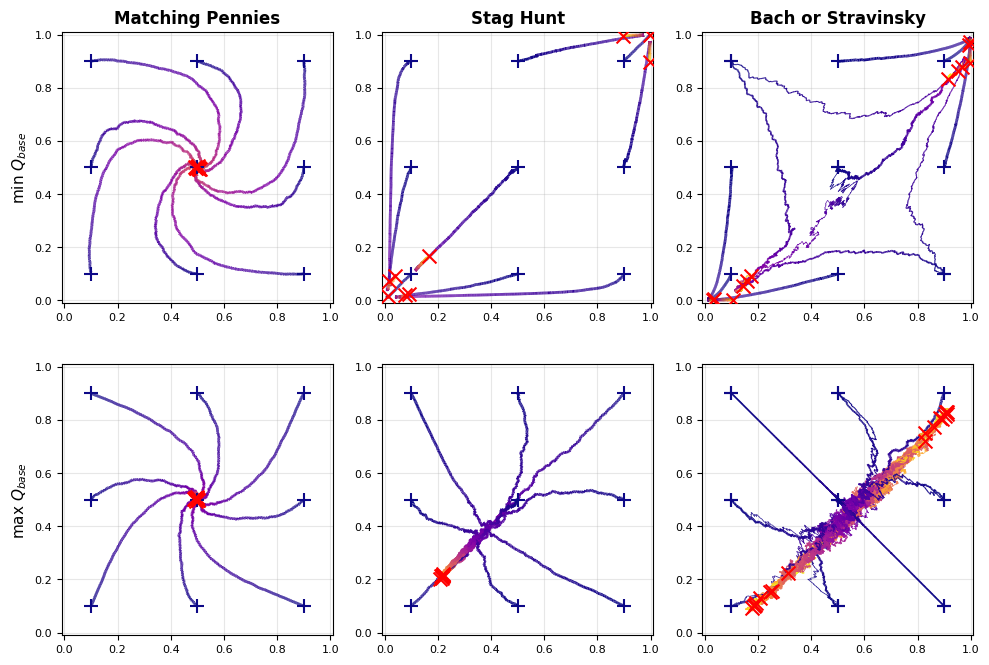

In [5]:
# Create 3x2 grid: columns = games (MP, SH, BS), rows = (min Qbase, max Qbase)
fig, axes = plt.subplots(2, 3, figsize=(10, 7), dpi=dpi)

marker_size = 100
color_start_scatter = plt.cm.plasma(0.0)
color_end_scatter = 'red'

base_value_arrays = [base_value_min_array, base_value_max_array]
row_labels = ['min $Q_{base}$', 'max $Q_{base}$']

for row_idx, base_value_array in enumerate(base_value_arrays):
    for col_idx in range(len(game_title_short)):
        ax = axes[row_idx, col_idx]
        
        reward_function = reward_function_array[col_idx]
        base_value = base_value_array[col_idx]
        num_time_steps = num_time_steps_array[col_idx]
        split_groups = split_groups_array[col_idx]  # Use split_groups setting for this game
        
        # Run stochastic simulation
        trajectories_group_C, trajectories_group_D, trajectories_group_C_size, trajectories_group_D_size = \
            run_stochastic_simulation(reward_function, num_time_steps, base_value, num_runs,
                                       learning_rate, discount_factor, temperature,
                                       initial_probability_pairs, split_groups=split_groups)
        
        # Plot trajectories for both groups
        for g, (group, group_sizes) in enumerate([(trajectories_group_C, trajectories_group_C_size),
                                                   (trajectories_group_D, trajectories_group_D_size)]):
            for i, trajectory in enumerate(group):
                if trajectory is not None:
                    prob_first_action_list = np.array([trajectory[0], trajectory[1]]).T
                    
                    # Create line segments for color gradient
                    lines = [[prob_first_action_list[j], prob_first_action_list[j+1]] 
                             for j in range(len(prob_first_action_list)-1)]
                    # Line width proportional to group size
                    size = 2 * group_sizes[i]
                    lc = LineCollection(lines, cmap='plasma', linewidths=max(size, 0.5), alpha=1)
                    lc.set_array(np.linspace(0, 1, len(prob_first_action_list)))
                    ax.add_collection(lc)
                    
                    # Plot start and end points
                    ax.scatter(prob_first_action_list[0, 0], prob_first_action_list[0, 1], marker='+',
                                color=color_start_scatter, zorder=10, s=marker_size)
                    ax.scatter(prob_first_action_list[-1, 0], prob_first_action_list[-1, 1], marker='x',
                                color=color_end_scatter, zorder=10, s=marker_size)

        # Subplot cosmetics
        ax.set_xlim(-0.01, 1.01)
        ax.set_ylim(-0.01, 1.01)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(labelsize=8)
        
        # Column titles (game names) - only on top row
        if row_idx == 0:
            ax.set_title(game_title[col_idx], fontsize=12, fontweight='bold')
        
        # Row labels - only on leftmost column
        if col_idx == 0:
            ax.set_ylabel(row_labels[row_idx], fontsize=11)

plt.tight_layout()

if SAVE_FIGURES:
    filename = f'Fig_Stochastic_AllGames_discount_{discount_factor}_temp_{temperature}_learningRate_{learning_rate}_numRuns_{num_runs}.jpg'
    plt.savefig(os.path.join(directory_for_figures, filename), dpi=dpi, bbox_inches='tight')

plt.show()